In [ ]:
from google.colab import files
uploaded = files.upload()


Saving netflix_movies_detailed_up_to_2025.csv to netflix_movies_detailed_up_to_2025.csv


In [ ]:
import pandas as pd

# Replace with your exact file name if it's different
df = pd.read_csv("netflix_movies_detailed_up_to_2025.csv")

# Basic info
print("✅ Dataset Loaded Successfully")
print("Shape (rows, columns):", df.shape)
print("\nColumns:\n", df.columns.tolist())

# Preview first 5 rows
print("\nFirst 5 rows:")
display(df.head())

# Check missing values
print("\nMissing Values (Top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))


✅ Dataset Loaded Successfully
Shape (rows, columns): (16000, 18)

Columns:
 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'genres', 'language', 'description', 'popularity', 'vote_count', 'vote_average', 'budget', 'revenue']

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471



Missing Values (Top 10):
duration       16000
country          466
cast             204
director         132
description      132
genres           107
type               0
show_id            0
title              0
date_added         0
dtype: int64


In [ ]:
# ====== Missing-value handling + preprocessing for recommender ======
# Run this in Google Colab after loading your cleaned CSV into the session.

import pandas as pd
import numpy as np
import re
from pathlib import Path

# 1) Load dataset (change filename if needed)
df = pd.read_csv("netflix_movies_detailed_up_to_2025.csv")   # or your cleaned CSV name

# 2) Quick missing-value overview (optional print)
print("Initial shape:", df.shape)
print("Missing counts (top):\n", df.isnull().sum().sort_values(ascending=False).head(20))

# ---------------------------
# 3) Decide column handling
# ---------------------------
# - duration: your earlier check showed it was fully missing. Drop it.
# - country, cast, director, genres, description: fill with placeholder or empty string
# - title always needed (should have no nulls)
# - other numeric columns (popularity, vote_average) are fine; they have no nulls per earlier check.

# Drop duration if it's all NaN or useless
if 'duration' in df.columns:
    # if all values are NaN or empty string, drop the column
    if df['duration'].isnull().all() or (df['duration'].astype(str).str.strip() == "").all():
        df.drop(columns=['duration'], inplace=True)
        print("Dropped 'duration' column (all missing).")
    else:
        # if some values exist you could parse them; otherwise fill NAs
        df['duration'] = df['duration'].fillna("Unknown")

# Fill missing textual fields with safe defaults
text_cols_fill_unknown = ['country', 'language']   # these are categorical; Unknown is fine
for c in text_cols_fill_unknown:
    if c in df.columns:
        df[c] = df[c].fillna("Unknown").astype(str)

# For fields that will be combined into text for vectorization, use empty string when missing
text_cols_for_tfidf = ['genres', 'description', 'director', 'cast']
for c in text_cols_for_tfidf:
    if c in df.columns:
        df[c] = df[c].fillna("").astype(str)   # empty string is best for TF-IDF combination

# Ensure title exists and is string
df['title'] = df['title'].astype(str)

# ---------------------------
# 4) Text cleaning function (for the fields that will be vectorized)
# ---------------------------
import unicodedata
def clean_text(s):
    """
    Lowercase, normalize unicode, remove punctuation (except keep spaces),
    remove extra whitespace. Returns cleaned string.
    """
    if not isinstance(s, str):
        return ""
    # normalize unicode
    s = unicodedata.normalize('NFKD', s)
    # lower
    s = s.lower()
    # remove things like URLs (rare), punctuation, special chars
    s = re.sub(r'http\S+', ' ', s)                   # remove urls
    s = re.sub(r'[^a-z0-9\s]', ' ', s)               # keep only alphanumeric+space
    s = re.sub(r'\s+', ' ', s).strip()               # collapse whitespace
    return s

# Apply cleaning to the columns used for text features
for col in ['title','genres','director','cast','description','language','country']:
    if col in df.columns:
        df[col + '_clean'] = df[col].apply(clean_text)

# 5) Special handling for genres (optional): convert "genre1, genre2" -> "genre1 genre2"
# We already cleaned punctuation; ensure comma-split genres join with space
if 'genres' in df.columns:
    # some rows may have comma-separated values; replace commas with space, then clean
    df['genres_clean'] = df['genres'].str.replace(',', ' ').astype(str).apply(clean_text)

# 6) Create combined_features for TF-IDF / vectorization
# Order: title, genres, director, cast, description, country, language
def make_combined(row):
    parts = []
    # pick the cleaned variants (if created), otherwise the raw
    for c in ['title_clean','genres_clean','director_clean','cast_clean','description_clean','country_clean','language_clean']:
        if c in row.index:
            val = row[c]
            if isinstance(val, str) and val.strip():
                parts.append(val)
    return " ".join(parts)

df['combined_features'] = df.apply(make_combined, axis=1)

# Quick check: show sample combined text
print("\nSample combined_features (3 rows):")
display(df[['title','combined_features']].head(3))

# 7) Optional: explode genres into separate rows for genre-specific analysis (not needed for TF-IDF)
if 'genres' in df.columns:
    # create an exploded dataframe for easier genre counts and charts (one row per genre)
    df_genres_exploded = df[['title','release_year']].copy()
    df_genres_exploded['genres_list'] = df['genres'].str.split(',')
    df_genres_exploded = df_genres_exploded.explode('genres_list')
    df_genres_exploded['genres_list'] = df_genres_exploded['genres_list'].fillna('').str.strip()
    # save exploded file
    df_genres_exploded.to_csv("netflix_genres_exploded.csv", index=False)
    print("Saved netflix_genres_exploded.csv for genre-level analysis.")

# 8) Remove duplicates (if any) — keep the first occurrence
before = df.shape[0]
df.drop_duplicates(subset=['title','release_year'], keep='first', inplace=True)
after = df.shape[0]
print(f"Dropped duplicates (title+year): {before-after} rows removed.")

# 9) Save cleaned dataframe for later use
out_name = "netflix_for_recommender.csv"
df.to_csv(out_name, index=False)
print(f"Saved cleaned dataframe to {out_name}. Shape now: {df.shape}")

# 10) Final missing-value summary (post-processing)
print("\nMissing counts after processing:\n", df.isnull().sum().sort_values(ascending=False).head(20))


Initial shape: (16000, 18)
Missing counts (top):
 duration        16000
country           466
cast              204
director          132
description       132
genres            107
type                0
show_id             0
title               0
date_added          0
rating              0
release_year        0
language            0
popularity          0
vote_count          0
vote_average        0
budget              0
revenue             0
dtype: int64
Dropped 'duration' column (all missing).

Sample combined_features (3 rows):


,title,combined_features
0,Shrek Forever After,shrek forever after comedy adventure fantasy a...
1,Inception,inception action science fiction adventure chr...
2,Harry Potter and the Deathly Hallows: Part 1,harry potter and the deathly hallows part 1 ad...


Saved netflix_genres_exploded.csv for genre-level analysis.
Dropped duplicates (title+year): 37 rows removed.
Saved cleaned dataframe to netflix_for_recommender.csv. Shape now: (15963, 25)

Missing counts after processing:
 show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
genres            0
language          0
description       0
popularity        0
vote_count        0
vote_average      0
budget            0
revenue           0
title_clean       0
genres_clean      0
director_clean    0
dtype: int64


✅ Cleaned dataset loaded successfully!
Shape: (15963, 25)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'genres', 'language', 'description', 'popularity', 'vote_count', 'vote_average', 'budget', 'revenue', 'title_clean', 'genres_clean', 'director_clean', 'cast_clean', 'description_clean', 'language_clean', 'country_clean', 'combined_features']


/tmp/ipython-input-3434167058.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='coolwarm')


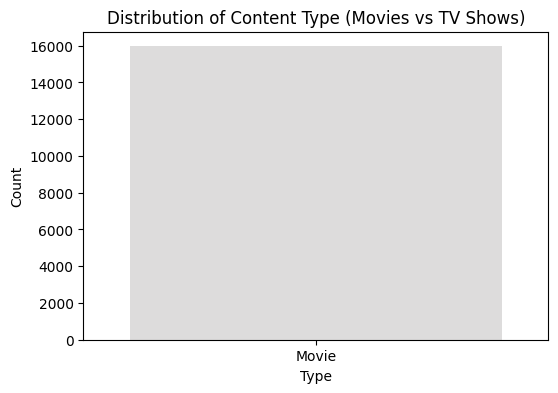

/tmp/ipython-input-3434167058.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


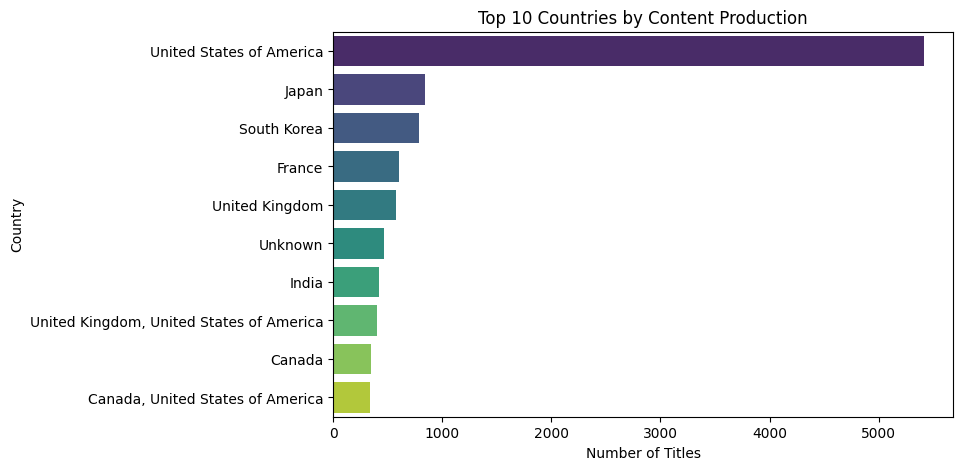

/tmp/ipython-input-3434167058.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=top_genres, palette='magma')


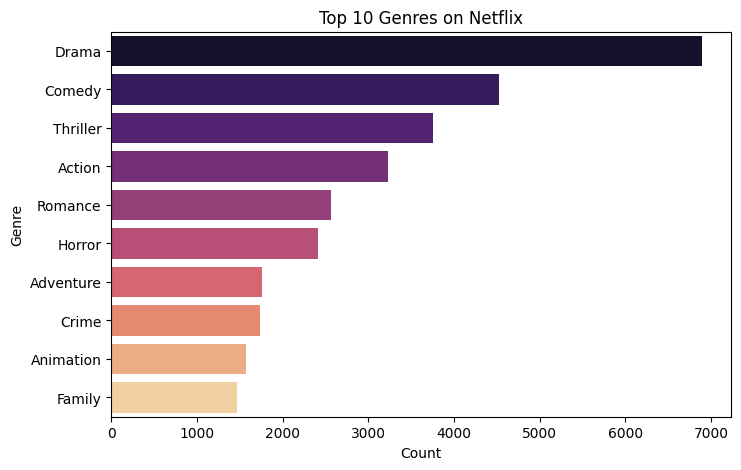

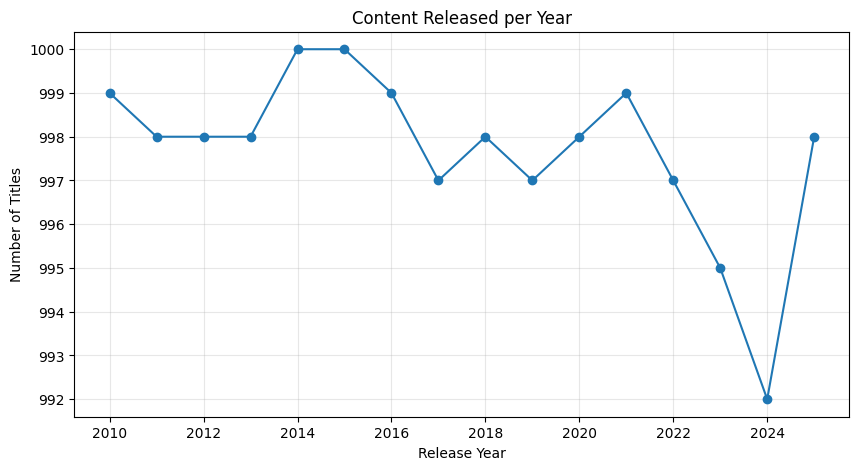

/tmp/ipython-input-3434167058.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index, palette='cubehelix')


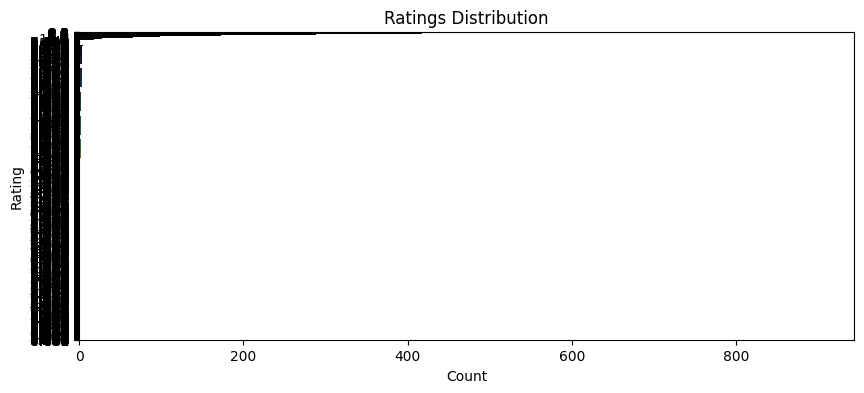

/tmp/ipython-input-3434167058.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Popularity', y='Genre', data=genre_popularity_df, palette='cool')


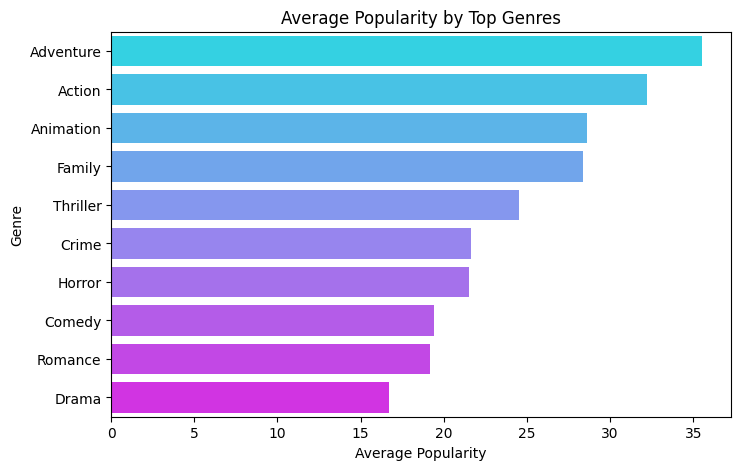

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load cleaned data
df = pd.read_csv("netflix_for_recommender.csv")

# Step 2: Basic info
print("✅ Cleaned dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# -------------------------------------------------
# 1️⃣ Content Type Distribution (Movies vs TV Shows)
# -------------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df, palette='coolwarm')
plt.title('Distribution of Content Type (Movies vs TV Shows)')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

# -------------------------------------------------
# 2️⃣ Top 10 Countries Producing Most Content
# -------------------------------------------------
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Content Production')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

# -------------------------------------------------
# 3️⃣ Genre Distribution (Top 10 Genres)
# -------------------------------------------------
# Split genres by commas and count them
from collections import Counter
genre_counts = Counter([g.strip() for sublist in df['genres'].dropna().str.split(',') for g in sublist])
top_genres = pd.DataFrame(genre_counts.most_common(10), columns=['Genre', 'Count'])

plt.figure(figsize=(8,5))
sns.barplot(x='Count', y='Genre', data=top_genres, palette='magma')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

# -------------------------------------------------
# 4️⃣ Content Release Trend by Year
# -------------------------------------------------
plt.figure(figsize=(10,5))
df['release_year'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Content Released per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------------------------
# 5️⃣ Ratings Distribution
# -------------------------------------------------
plt.figure(figsize=(10,4))
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index, palette='cubehelix')
plt.title('Ratings Distribution')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

# -------------------------------------------------
# 6️⃣ Average Popularity by Genre (Top 10)
# -------------------------------------------------
# Calculate mean popularity for each genre
genre_popularity = []
for genre in top_genres['Genre']:
    avg_pop = df[df['genres'].str.contains(genre, case=False, na=False)]['popularity'].mean()
    genre_popularity.append((genre, avg_pop))

genre_popularity_df = pd.DataFrame(genre_popularity, columns=['Genre', 'Avg_Popularity']).sort_values(by='Avg_Popularity', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Avg_Popularity', y='Genre', data=genre_popularity_df, palette='cool')
plt.title('Average Popularity by Top Genres')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.show()


In [ ]:
# -----------------------------------------------------------
# 🧠 Netflix Content-Based Recommendation System
# -----------------------------------------------------------

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1️⃣ Load cleaned dataset
df = pd.read_csv("netflix_for_recommender.csv")

print("✅ Dataset for recommender loaded successfully!")
print("Shape:", df.shape)

# -----------------------------------------------------------
# 2️⃣ Create a combined text feature (to represent each movie)
# -----------------------------------------------------------
# We’ll merge multiple useful text columns into one large text string
df['combined_features'] = (
    df['title'].fillna('') + ' ' +
    df['genres'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['director'].fillna('') + ' ' +
    df['cast'].fillna('')
)

# -----------------------------------------------------------
# 3️⃣ Convert text data into TF-IDF matrix (numerical vectors)
# -----------------------------------------------------------
# TF-IDF: converts text → weighted numbers that represent importance of each word
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

print("✅ TF-IDF matrix created! Shape:", tfidf_matrix.shape)

# -----------------------------------------------------------
# 4️⃣ Compute cosine similarity between all titles
# -----------------------------------------------------------
# Cosine similarity tells how “similar” two vectors (movies) are
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# -----------------------------------------------------------
# 5️⃣ Function to recommend similar movies/shows
# -----------------------------------------------------------
def recommend_movie(title, n=5):
    """
    Given a movie title, return top N similar titles.
    """
    if title not in df['title'].values:
        return f"❌ '{title}' not found in dataset."

    # Get index of the movie that matches the title
    idx = df.index[df['title'] == title][0]

    # Get pairwise similarity scores for that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort movies by similarity score (descending)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top N most similar movies (skip first one — itself)
    sim_indices = [i[0] for i in sim_scores[1:n+1]]

    # Return the top N similar titles
    return df['title'].iloc[sim_indices].tolist()

# -----------------------------------------------------------
# 6️⃣ Try some test recommendations
# -----------------------------------------------------------
print("\n🎬 Example Recommendations:")
print("Movies similar to 'Inception':")
print(recommend_movie("Inception", n=5))

print("\nMovies similar to 'Harry Potter and the Deathly Hallows: Part 1':")
print(recommend_movie("Harry Potter and the Deathly Hallows: Part 1", n=5))


✅ Dataset for recommender loaded successfully!
Shape: (15963, 25)
✅ TF-IDF matrix created! Shape: (15963, 67507)

🎬 Example Recommendations:
Movies similar to 'Inception':
['Inception: The Cobol Job', 'Don Jon', 'Pinocchio', 'The Revenant', 'The Dark Knight Rises']

Movies similar to 'Harry Potter and the Deathly Hallows: Part 1':
['Harry Potter and the Deathly Hallows: Part 2', '50 Greatest Harry Potter Moments', 'Harry Potter 20th Anniversary: Return to Hogwarts', 'The Thing About Harry', 'David Holmes: The Boy Who Lived']


In [ ]:
!pip install streamlit pyngrok scikit-learn pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 51.5 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load the cleaned dataset
df = pd.read_csv("netflix_for_recommender.csv")

# Create combined feature text
df['combined_features'] = (
    df['genres'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['cast'].fillna('') + ' ' +
    df['director'].fillna('') + ' ' +
    df['country'].fillna('')
)

# TF-IDF and similarity
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_features'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Recommendation function
def get_recommendations(title, cosine_sim=cosine_sim):
    if title not in df['title'].values:
        return ["Title not found in dataset."]
    idx = df[df['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:6]
    movie_indices = [i[0] for i in sim_scores]
    return df['title'].iloc[movie_indices].tolist()

# Streamlit interface
st.title("🎬 Netflix Movie Recommender")
st.write("Search any movie or show and get similar recommendations!")

movie_name = st.text_input("Enter a movie name:")
if st.button("Recommend"):
    results = get_recommendations(movie_name)
    st.write("### Recommended Titles:")
    for r in results:
        st.write(f"- {r}")


Writing app.py


In [ ]:
|import os

# List all CSV files in your current directory
[x for x in os.listdir() if x.endswith('.csv')]


['netflix_movies_detailed_up_to_2025.csv',
 'netflix_for_recommender.csv',
 'netflix_genres_exploded.csv']

In [ ]:
from google.colab import files
files.download("netflix_for_recommender.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving netflix_for_recommender.csv to netflix_for_recommender.csv


In [ ]:
!pip install pyngrok -q


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# Load dataset
df = pd.read_csv("netflix_for_recommender.csv")

st.title("🎬 Movie Recommender System (TF-IDF based)")

movie_name = st.text_input("Enter a movie name:")

if st.button("Recommend"):
    if movie_name.strip() == "":
        st.warning("Please enter a movie name.")
    else:
        tfidf = TfidfVectorizer(stop_words='english')
        tfidf_matrix = tfidf.fit_transform(df['combined_features'])
        cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

        indices = pd.Series(df.index, index=df['title']).drop_duplicates()

        if movie_name not in indices:
            st.error("❌ Movie not found in dataset.")
        else:
            # ✅ New: show searched movie name and confirmation
            st.markdown(f"🎥 **You searched for:** `{movie_name}`")
            st.info("✅ Movie found in dataset!")

            idx = indices[movie_name]
            sim_scores = list(enumerate(cosine_sim[idx]))
            sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
            sim_scores = sim_scores[1:6]
            movie_indices = [i[0] for i in sim_scores]

            # ✅ New: clearer section header
            st.success("🎬 Top 5 Recommended Movies:")
            for m in df['title'].iloc[movie_indices]:
                st.write("🍿", m)



Overwriting app.py


In [ ]:
!pip install streamlit pyngrok -q
from pyngrok import ngrok

# 🔐 Set ngrok token
ngrok.set_auth_token("35ILBC7U91CC5EK5hDCKjDRGpgO_4WBjkjDSgzhq2bM5J8WXo")

# 🚀 Run Streamlit app
!streamlit run app.py &>/dev/null &
public_url = ngrok.connect(8501)
print("🌍 Your public app URL:", public_url)


🌍 Your public app URL: NgrokTunnel: "https://unaggravated-unignited-kyndall.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
import pandas as pd

df = pd.read_csv("netflix_for_recommender.csv")
print("Total movies:", len(df))
print("\nSample movie titles in dataset:")
print(df['title'].head(20).tolist())  # Show first 20 titles

# Optional: check if specific ones exist
for movie in ["Titanic", "Avatar", "Inception", "Harry Potter and the Deathly Hallows: Part 1"]:
    print(f"{movie} present:", movie in df['title'].values)


Total movies: 15963

Sample movie titles in dataset:
['Shrek Forever After', 'Inception', 'Harry Potter and the Deathly Hallows: Part 1', 'Tangled', 'How to Train Your Dragon', 'Shutter Island', 'The Karate Kid', 'Iron Man 2', 'Grown Ups', 'Room in Rome', 'Despicable Me', 'Toy Story 3', 'The Twilight Saga: Eclipse', 'Alice in Wonderland', 'A Serbian Film', 'Undisputed III: Redemption', 'The Social Network', 'Three Steps Above Heaven', 'Percy Jackson & the Olympians: The Lightning Thief', 'The Town']
Titanic present: False
Avatar present: False
Inception present: True
Harry Potter and the Deathly Hallows: Part 1 present: True
